In [16]:
# the following data displays video game sales as of the 22nd of December, 2016.
# columns contain information such as: the year of the game's release, the game's name, publisher, and sales across various regions,
# as well as extra information on some games such as their critique scores, developer and ESRB (maturity) rating. 
# in this project, I will clean the raw data, dropping unnecessary columns.
# I will then analyse the data, discovering if there are trends to video game sales in relation to aspects such as the genre, publisher, platform etc. 

# first, I will import all packages I will need in this project
# and read in the data

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline

pd.options.mode.chained_assignment = None

df = pd.read_csv(r"C:\Users\callu\Downloads\Video_Games_Sales_as_at_22_Dec_2016.csv")

In [17]:
# now, look at a brief overview of the data

df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# immediately I can see some rows missing values in the last 6 columns; critic_score, critic_count, user_score, user_count, developer and rating.
# another thing to note is that year_of_release looks to be of type float, so this should be changed to remove the decimal point. 
# let's first check the data types for each column

df.dtypes

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
dtype: object

In [19]:
# there are three things to note from this:
# 1) year_of_release is in fact a float, so this shall be changed to an int.
# 2) user_score is stored as an object, not a float like critic_score. this will need to be changed too. 
# 3) critic_count and user_count can be changed to int as they will all be integer values. 

# let's change year_of_release first.

df['Year_of_Release'] = df['Year_of_Release'].astype('Int64')

In [20]:
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# next, let's change both critic_count and user_count to integer values

df['Critic_Count'] = df['Critic_Count'].astype('Int64')

df['User_Count'] = df['User_Count'].astype('Int64')

In [22]:
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51,8,322,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,<NA>,NaN,<NA>,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73,8.3,709,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73,8,192,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,<NA>,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16715,LMA Manager 2007,X360,2006,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16717,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN


In [23]:
# now, let's convert user_score to be a float value

df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

In [24]:
df.dtypes

Name                object
Platform            object
Year_of_Release      Int64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count         Int64
User_Score         float64
User_Count           Int64
Developer           object
Rating              object
dtype: object

In [25]:
# now that all columns have correct data types, let's check if there are any outliers

df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16450.0,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.0,7590.000000,7590.0
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,7.125046,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,1.500006,561.282326
min,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.0,0.000000,4.0
25%,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.0,6.400000,10.0
50%,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.0,7.500000,24.0
75%,2010.0,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.0,8.200000,81.0
max,2020.0,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.0,9.700000,10665.0


In [30]:
# this data shows there there will be a right-skewed distribution, and don't have any outliers.
# while the maximum values for sales are far higher than the median values, these values can be justified as blockbuster titles in the gaming industry.
# therefore, I will not treat these values as outliers for removal.
# a right-skewed distribution can be expected because there are far more low/zero values than there are extremely high values.
# for example, the mean NA_Sales is 0.26, whereas the median is 0.08. this is a big difference, meaning the data will be skewed. 
# in general, it can be assumed that all regional sales data will be highly skewed, as at least 25% of entries are zero values. 
# there can be many reasons for this, such as region-specific releases, or low-selling titles. 
# because of this, I will use the median values alongside mean values to provide better insights. 

# here are the questions I will try to answer with my analysis:

# 1) what are the top selling games for each region? 
# 2) which genres are the most popular? are there regions that enjoy certain genres more than others?
# 3) are console sales rising or falling with each generation?
# 4) is there a correlation between critic scores and sales?
# 5) does the publisher effect the game's success?
# 6) does the game's ESRB (maturity) rating effect sales?

# first, I will analyse the top 10 games (in terms of sales revenue) for each region.
# the sub questions I will be answering for question 1 are:
# are the same games appearing across each region?
# are certain platforms dominant in certain regions?
# are these games newer or older?

top_na = df.sort_values(by='NA_Sales', ascending=False)[['Name', 'Platform', 'Year_of_Release', 'NA_Sales']].head(10)
top_eu = df.sort_values(by='EU_Sales', ascending=False)[['Name', 'Platform', 'Year_of_Release', 'EU_Sales']].head(10)
top_jp = df.sort_values(by='JP_Sales', ascending=False)[['Name', 'Platform', 'Year_of_Release', 'JP_Sales']].head(10)

In [31]:
top_na

,Name,Platform,Year_of_Release,NA_Sales
0,Wii Sports,Wii,2006,41.36
1,Super Mario Bros.,NES,1985,29.08
9,Duck Hunt,NES,1984,26.93
5,Tetris,GB,1989,23.20
2,Mario Kart Wii,Wii,2008,15.68
3,Wii Sports Resort,Wii,2009,15.61
14,Kinect Adventures!,X360,2010,15.00
8,New Super Mario Bros. Wii,Wii,2009,14.44
7,Wii Play,Wii,2006,13.96
18,Super Mario World,SNES,1990,12.78


In [32]:
top_eu

,Name,Platform,Year_of_Release,EU_Sales
0,Wii Sports,Wii,2006,28.96
2,Mario Kart Wii,Wii,2008,12.76
10,Nintendogs,DS,2005,10.95
3,Wii Sports Resort,Wii,2009,10.93
19,Brain Age: Train Your Brain in Minutes a Day,DS,2005,9.20
7,Wii Play,Wii,2006,9.18
6,New Super Mario Bros.,DS,2006,9.14
16,Grand Theft Auto V,PS3,2013,9.09
4,Pokemon Red/Pokemon Blue,GB,1996,8.89
15,Wii Fit Plus,Wii,2009,8.49


In [33]:
top_jp

,Name,Platform,Year_of_Release,JP_Sales
4,Pokemon Red/Pokemon Blue,GB,1996,10.22
12,Pokemon Gold/Pokemon Silver,GB,1999,7.20
1,Super Mario Bros.,NES,1985,6.81
6,New Super Mario Bros.,DS,2006,6.50
20,Pokemon Diamond/Pokemon Pearl,DS,2006,6.04
27,Pokemon Black/Pokemon White,DS,2010,5.65
25,Pokemon Ruby/Pokemon Sapphire,GBA,2002,5.38
43,Animal Crossing: Wild World,DS,2005,5.33
26,Brain Age 2: More Training in Minutes a Day,DS,2005,5.32
215,Monster Hunter Freedom 3,PSP,2010,4.87


In [36]:
# from these tables, it is shown that there is no game that appears in all 3 regions' top 10 list.
# the top 5 games globally appeared in two regions' lists, as well as the 7th and 8th ranked. 
# lets look at each region's average year_of_release and sales

top_na[['Year_of_Release', 'NA_Sales']].mean()

Year_of_Release    1999.6
NA_Sales           20.804
dtype: Float64

In [37]:
top_eu[['Year_of_Release', 'EU_Sales']].mean()

Year_of_Release    2006.3
EU_Sales           11.759
dtype: Float64

In [38]:
top_jp[['Year_of_Release', 'JP_Sales']].mean()

Year_of_Release    2002.4
JP_Sales            6.332
dtype: Float64

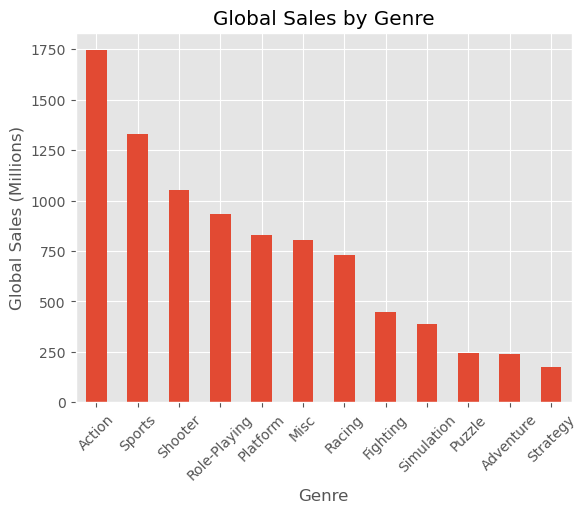

In [39]:
# one of two things can be interpreted from these average release year values:
# 1) Europeans prefer newer games than North Americans and Japanese
# or
# 2) European gaming is growing and sales are increasing over the years
# the average sales show that the North American market is much larger than that of Europe and Japan, netting more than both combined.

# now, to find which genres are most popular, and whether different regions prefer different genres.

genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

genre_sales.plot(kind='bar')

plt.title('Global Sales by Genre')
plt.ylabel('Global Sales (Millions)')
plt.xlabel('Genre')
plt.xticks(rotation=45)

plt.show()

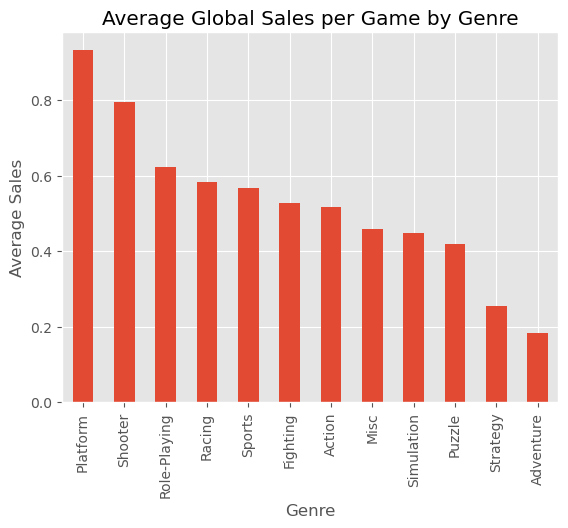

In [41]:
# this table shows that the genre with the highest global sales revenue is Action games. 
# strategy, adventure, and puzzle games have produced the lowest revenue globally. 

# however, this table doesn't show the full truth. what if action games have the highest revenue because the genre has more games than others?
# the mean sales per game will better determine the popularity of a genre as it will show how much the average title will sell.

genre_avg = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

genre_avg.plot(kind='bar')

plt.title('Average Global Sales per Game by Genre')
plt.ylabel('Average Sales')
plt.xlabel('Genre')
plt.show()

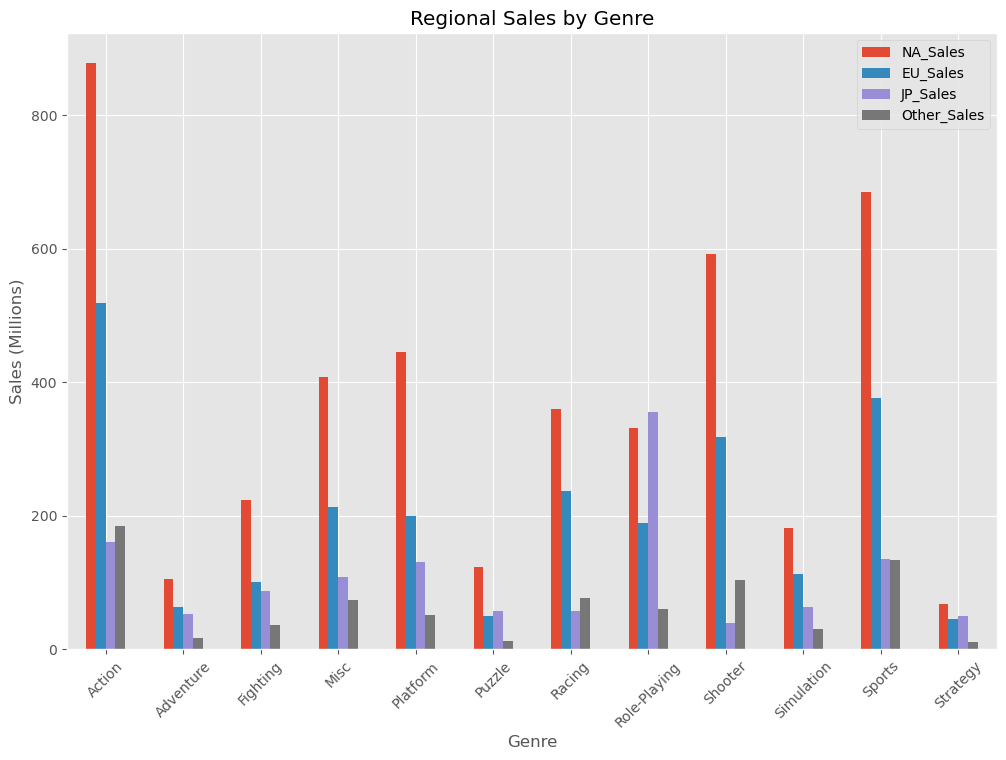

In [43]:
# this table shows that, actually, platform and shooter games sell more per title than the rest, with action games being only the 7th ranking genre.
# puzzle, strategy and adventure are still the lowest selling genres, however, making it clear these are less popular than other genres. 

# these tables only tell the story globally. each region will have different preferred genres.
# therefore, it is important to analyse if the favoured genres globally are also favoured in each region

regional_genres = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

regional_genres.plot(kind='bar', figsize=(12,8))

plt.title('Regional Sales by Genre')
plt.ylabel('Sales (Millions)')
plt.xlabel('Genre')
plt.xticks(rotation=45)

plt.show()

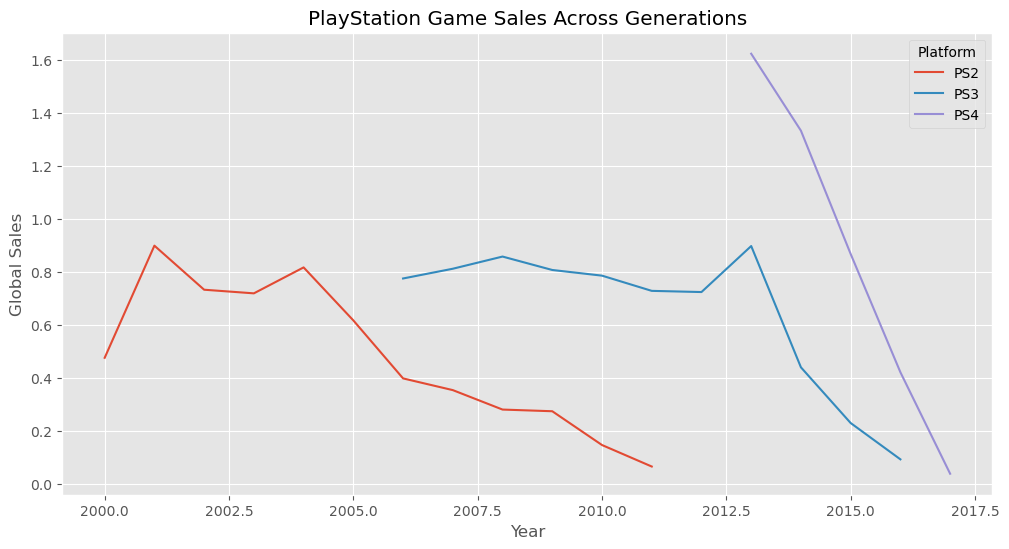

In [54]:
# from this chart, we can see NA, EU and other sales share the same top 3 genres in terms of sales revenue.
# however, Japan clearly prefer role-playing games to any other genre, showing over double the sales of any other genre.
# this shows that while, generally, regions prefer similar genres, role-playing games are majorly popular in Japan, who make up more sales than NA. 

# for question 3, I am going to analyse sales across the playstation generations. 
# this data is as of December of 2016, which was only 3 years into the ps4's life cycle, 
# so total sales per console won't accurately display if each generation is getting more popular with video game sales.

ps_sales = df[df['Platform'].isin(['PS2','PS3','PS4'])]

ps_sales_avg = ps_sales.groupby(['Year_of_Release','Platform'])['Global_Sales'].mean().unstack()

ps_sales_avg.plot(figsize=(12,6))

plt.title('PlayStation Game Sales Across Generations')
plt.ylabel('Global Sales')
plt.xlabel('Year')

plt.show()

In [56]:
# the visualisation suggests that the average game sales are increasing per generation for several reasons.
# reason 1 is that with each generation, the initial average global sales start higher than the previous generation. 
# this is possbily due to growth in the gaming industry and an increasing market size over time
# reason 2 is that each generation experiences a clear sales peak followed by a gradual decline following the next generation's release.
# this pattern likely reflects the consumer's natural migration towards newer hardware over time. 

# to answer question 4, I first need a cleaned dataframe that contains only the rows which contain critic scores.

critic_df = df.dropna(subset=['Critic_Score', 'Global_Sales'])
critic_df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51,8.0,322,Nintendo,E
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73,8.3,709,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73,8.0,192,Nintendo,E
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65,8.5,431,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41,6.6,129,Nintendo,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16700,Breach,PC,2011,Shooter,Destineer,0.01,0.00,0.00,0.00,0.01,61.0,12,5.8,43,Atomic Games,T
16701,Bust-A-Move 3000,GC,2003,Puzzle,Ubisoft,0.01,0.00,0.00,0.00,0.01,53.0,4,NaN,<NA>,Taito Corporation,E
16702,Mega Brain Boost,DS,2008,Puzzle,Majesco Entertainment,0.01,0.00,0.00,0.00,0.01,48.0,10,NaN,<NA>,Interchannel-Holon,E
16706,STORM: Frontline Nation,PC,2011,Strategy,Unknown,0.00,0.01,0.00,0.00,0.01,60.0,12,7.2,13,SimBin,E10+


In [57]:
# now, I can calculate the correlation

critic_df['Critic_Score'].corr(critic_df['Global_Sales'])


np.float64(0.24547067750675447)

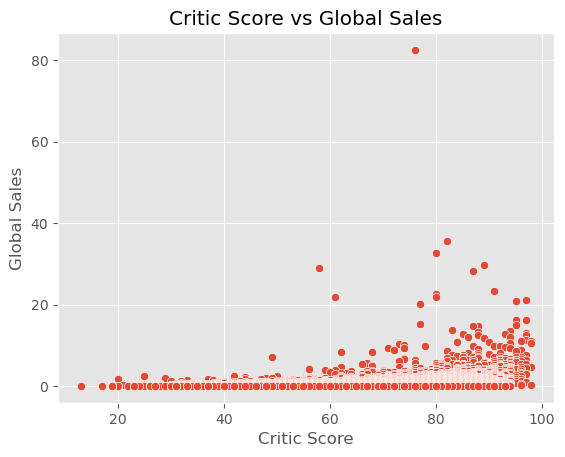

In [61]:
# the correlation is positive, but it is weak. 
# a scatter plot can best visualise the correlation

sns.scatterplot(
    data=critic_df,
    x='Critic_Score',
    y='Global_Sales'
)

plt.title('Critic Score vs Global Sales')
plt.ylabel('Global Sales')
plt.xlabel('Critic Score')
plt.show()

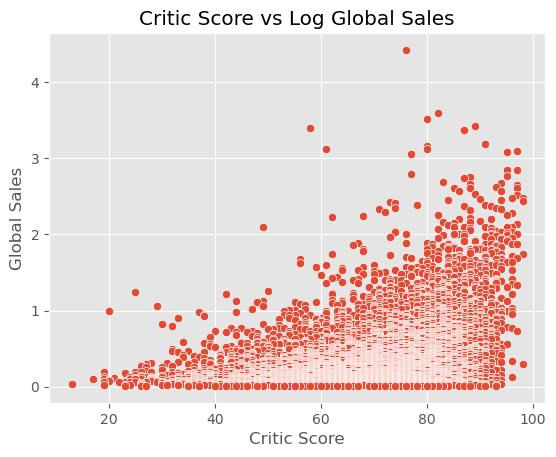

In [62]:
# because of some blockbuster games with high global sales, it is hard to see the correlation effectively.
# using log sales can better distribute the values and show a clearer relationship

critic_df['Log_Global_Sales'] = np.log1p(critic_df['Global_Sales'])

sns.scatterplot(
    data=critic_df,
    x='Critic_Score',
    y='Log_Global_Sales'
)

plt.title('Critic Score vs Log Global Sales')
plt.ylabel('Global Sales')
plt.xlabel('Critic Score')
plt.show()

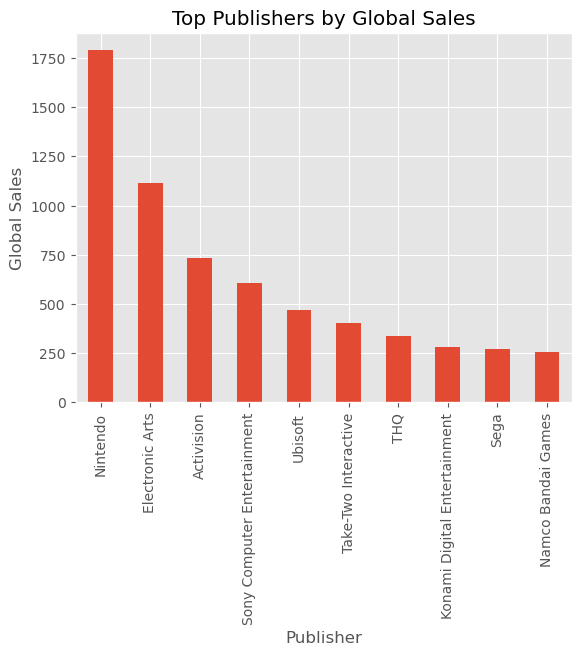

In [82]:
# the scatter plot represent a moderate positive corrrelation between the critic's score and global sales,
# which suggests that higher rated games usually achieve more sales. 
# however, the relationship is not strong enough to imply that there is a causation, 
# which lead to indicate that other factors impact the sales performance more. 

# the penultimate question will analyse if the game's publisher effects the sales of the game.

publisher_sales = (df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False))
top_publishers = publisher_sales.head(10)
top_publishers.plot(kind='bar')

plt.title('Top Publishers by Global Sales')
plt.ylabel('Global Sales')
plt.xlabel('Publisher')

plt.show()

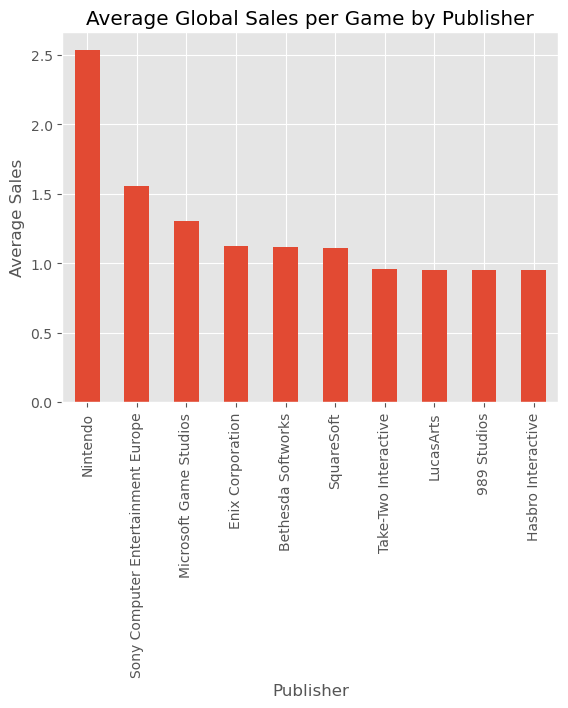

In [84]:
# this bar chart shows the total global sales per publisher, but the average sales per publisher is needed to better analyse their impact.
# publishers for this dataset should have a minimum games published, so I will go with 10

publisher_counts = df['Publisher'].value_counts()

major_publishers = publisher_counts[publisher_counts >= 10].index

filtered_publishers = df[df['Publisher'].isin(major_publishers)]

publisher_avg_filtered = (filtered_publishers.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending=False).head(10))

publisher_avg_filtered.plot(kind='bar')

plt.title('Average Global Sales per Game by Publisher')
plt.ylabel('Average Sales')

plt.show()

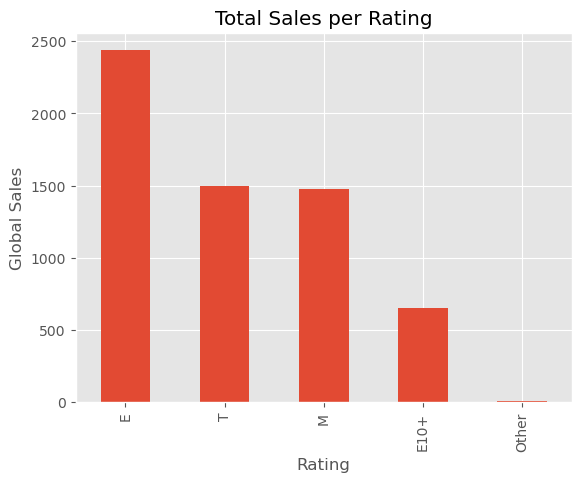

In [88]:
# this new graph shows that only Nintendo and Take-Two Interactive feature in both total and average sales per publisher.
# because of this, it can be interpreted that publishers that have higher overall sales are likely larger publishers whom have more titles released,
# and that the overall scale of the publisher does not always correspond to how well each individual title will succeed.

# the final question to be answered is whether the ESRB rating effects how much a title sells.

# the 8 ratings displayed are as follows:
    # E - Everyone
    # E10+ - Everyone aged 10 and older
    # T - Teen (13+)
    # M - Mature (17+)
    # AO - Adults Only (18+)
    # RP - Rating Pending (no rating) 
    # K-A - Kids-Adults (outdated, replaced by E)
    # EC - Early Childhood (initially 3+, made redundant and replaced by E)

# because of the latter 4's popularity in this data, I will group them as "other" for better readability.

rare_ratings = ['AO', 'RP', 'K-A', 'EC']
df['Rating_Grouped'] = df['Rating'].replace(rare_ratings, 'Other')

rating_df = df.dropna(subset=['Rating', 'Global_Sales'])
rating_sales = (rating_df.groupby('Rating_Grouped')['Global_Sales'].sum().sort_values(ascending=False))
rating_sales.plot(kind='bar')

plt.title('Total Sales per Rating')
plt.ylabel('Global Sales')
plt.xlabel('Rating')

plt.show()

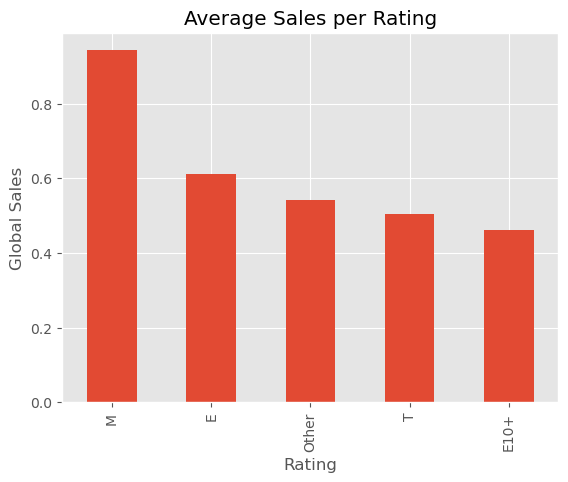

In [90]:
# this shows that the E rating has the highest number of overall sales, but what do the mean and median values for these ratings explain?

rating_sales = (rating_df.groupby('Rating_Grouped')['Global_Sales'].mean().sort_values(ascending=False))
rating_sales.plot(kind='bar')

plt.title('Average Sales per Rating')
plt.ylabel('Global Sales')
plt.xlabel('Rating')

plt.show()

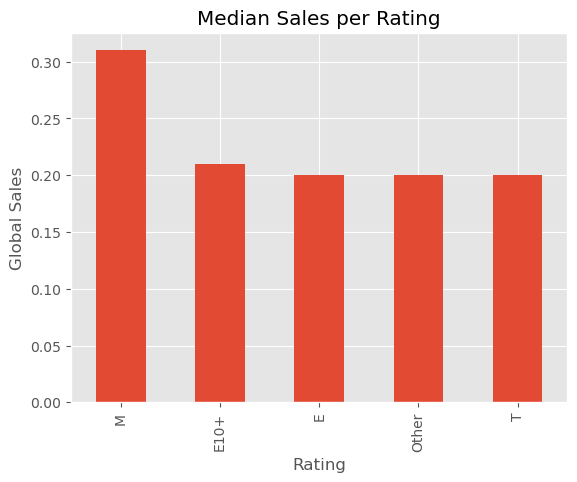

In [91]:
rating_sales = (rating_df.groupby('Rating_Grouped')['Global_Sales'].median().sort_values(ascending=False))
rating_sales.plot(kind='bar')

plt.title('Median Sales per Rating')
plt.ylabel('Global Sales')
plt.xlabel('Rating')

plt.show()

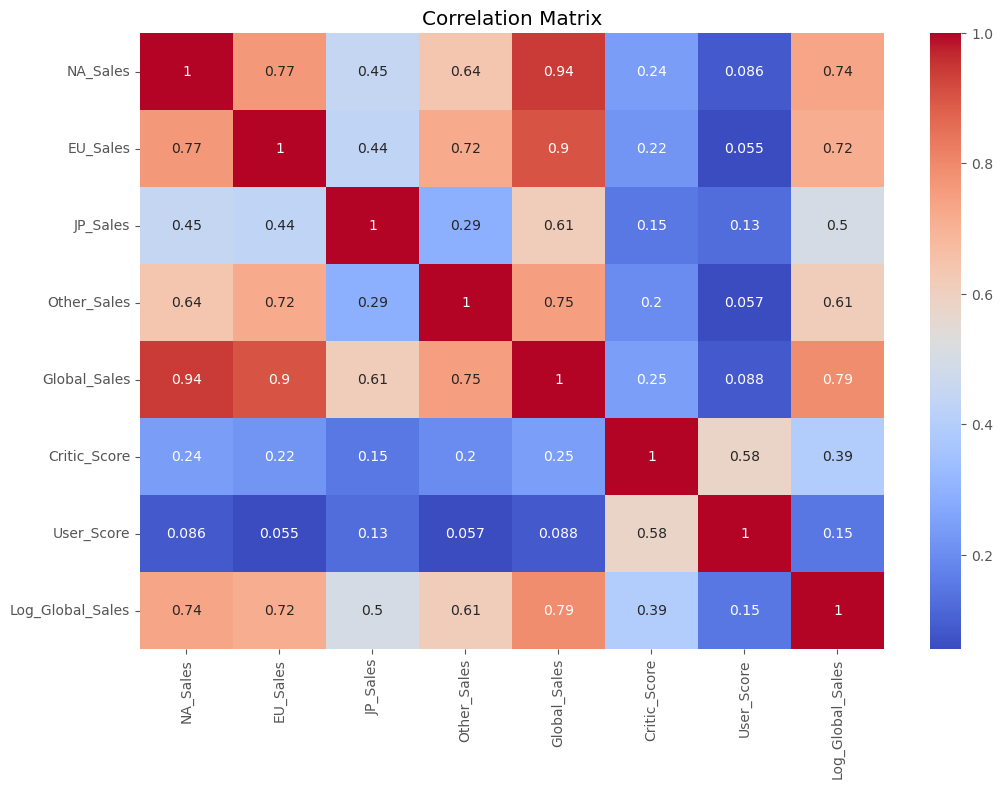

In [101]:
# this shows that while E rated games generated the highest total sales, median and mean sales per game provided a more balanced comparison
# by reducing the influence of blockbuster titles, which revealed that M rated games sell more per game than any other rating. 

# finally, I will visualise a correlation matrix for all data. 

df['Log_Global_Sales'] = np.log1p(df['Global_Sales'])

matrix_df = df.select_dtypes(include=['float64'])
matrix_df['Log_Global_Sales'] = df['Log_Global_Sales']

correlation_matrix = matrix_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

In [102]:
# this correlation matrix proves that which has already been analysed:
    # each sales relationship have high correlations, with NA being the highest correlating factor towards global sales.
    # critic score has a moderately low correlation to global sales, indicating critic scores do not play a large factor in the game's sales.

# the final row, being log global sales, better represents the correlation that factors have on global sales as it 
# reduces the high skew that blockbuster games cause on the data. 

In [103]:
# across all analyses, there is a consistent pattern: no single factor determines a game's success on the market.
# sales are influenced by a combination of factors, such as patform generation, genre popularity, regional preference and commercial factors
# such as the publisher's size.

# several limitations should be noted, such as missing values in columns such as critic score, which led to reduced sample sizing.
# in addition, sales distrivutions are heavily right-skewed, which led mean values to be effected heavily by blockbuster titles.
# the dataset also does not include other major external factors such as marketing spend or game pricing.

# overall, it can be deduced that video game success is driven by multiple factors, rather than one single factor.
# while some factors give evidence to have slight effects, no one factor greatly determines the overall success of the game in terms of sales. 